# Session 2, Block 2 &mdash; Data Visualization & EDA
**Data Science Techniques and Real-World Applications &mdash; WS 2026**

**Zahra Sharafi**

**Frankfurt School of Finance and Management**

Thursday 10 September 2026 

We'll keep using the tech-stocks data from Block 1, and bring in one classic teaching dataset
(restaurant tips) for variety in the EDA section.


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_excel("data/techstocks.xlsx", sheet_name="main")
df.head()

,PERMNO,Names Date,Ticker Symbol,Company Name,Price or Bid/Ask Average,Returns,Return on the S&P 500 Index
0,14542,2018-01-02,GOOG,ALPHABET INC,1065.000000,0.017775,0.008303
1,14542,2018-01-03,GOOG,ALPHABET INC,1082.479980,0.016413,0.006399
2,14542,2018-01-04,GOOG,ALPHABET INC,1086.400024,0.003621,0.004029
3,14542,2018-01-05,GOOG,ALPHABET INC,1102.229980,0.014571,0.007034
4,14542,2018-01-08,GOOG,ALPHABET INC,1106.939941,0.004273,0.001662


## <span style="color:#1e3a8a">Matplotlib essentials</span>

Matplotlib is the foundation almost every other Python plotting library (including Seaborn) is
built on. Two ways to use it:

- **pyplot (state-machine) API** &mdash; quick, implicit, great for a one-off plot: `plt.plot(...)`.
- **Object-oriented API** &mdash; explicit `fig, ax = plt.subplots()`, then call methods on `ax`.
  More verbose, but the only sane way once you have multiple subplots to manage.

We'll mostly use pyplot for speed, and switch to the OO style when we need more than one axes.


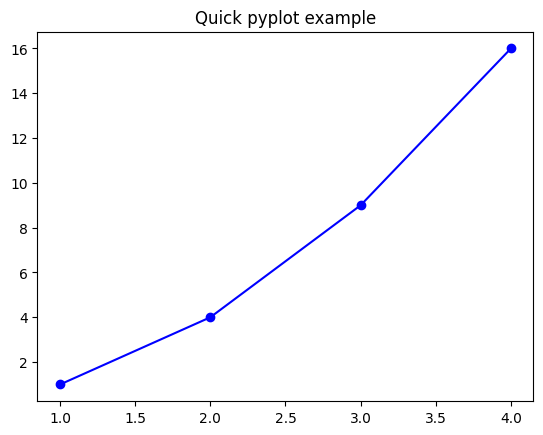

In [13]:
# pyplot style: quick and implicit
plt.plot([1, 2, 3, 4], [1, 4, 9, 16], "b-o")
plt.title("Quick pyplot example")
plt.show()

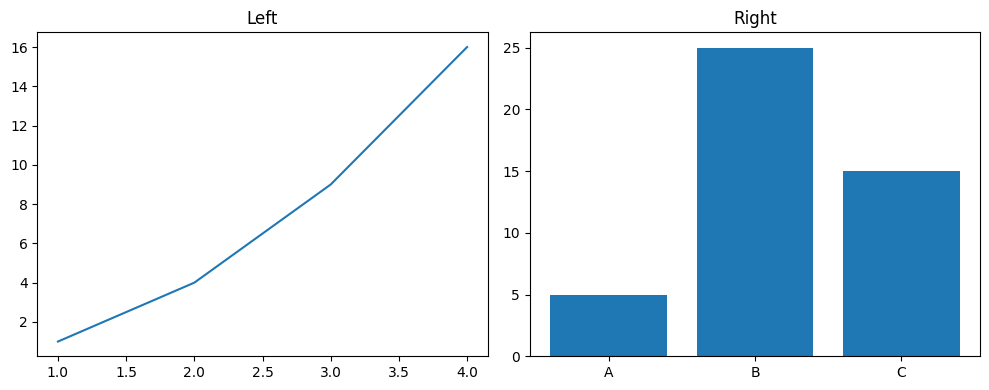

In [14]:
# OO style: explicit figure and axes -- needed once you have multiple subplots
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].plot([1, 2, 3, 4], [1, 4, 9, 16])
axes[0].set_title("Left")

axes[1].bar(["A", "B", "C"], [5, 25, 15])
axes[1].set_title("Right")

fig.tight_layout()
plt.show()

### A few common plot types

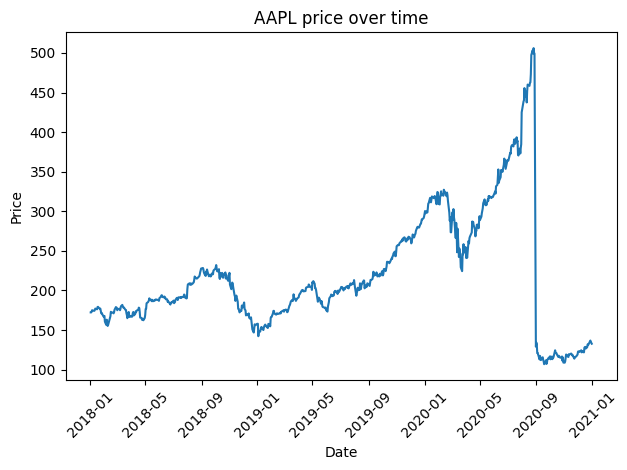

In [15]:
aapl = df[df["Ticker Symbol"] == "AAPL"].sort_values("Names Date")

plt.plot(aapl["Names Date"], aapl["Price or Bid/Ask Average"])
plt.title("AAPL price over time")
plt.xlabel("Date")
plt.ylabel("Price")
plt.xticks(rotation=45)   # dates overlap otherwise -- angle them so they stay readable
plt.tight_layout()       # make room for the angled labels so they do not get cut off
plt.show()

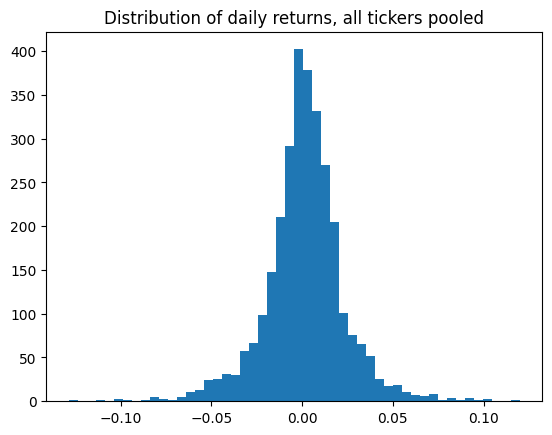

In [16]:
plt.hist(df["Returns"], bins=50)
plt.title("Distribution of daily returns, all tickers pooled")
plt.show()

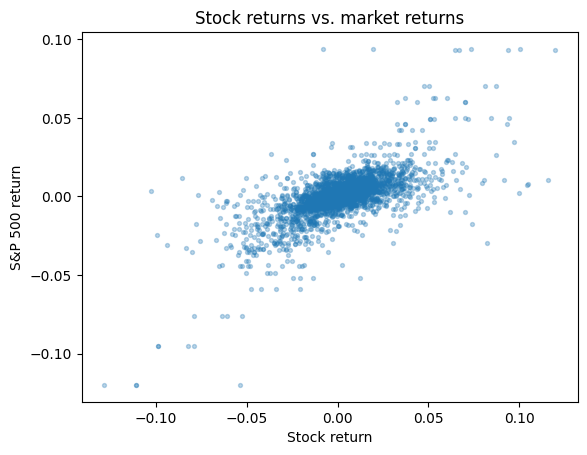

In [17]:
plt.scatter(df["Returns"], df["Return on the S&P 500 Index"], alpha=0.3, s=8)
plt.xlabel("Stock return")
plt.ylabel("S&P 500 return")
plt.title("Stock returns vs. market returns")
plt.show()

## <span style="color:#1e3a8a">Seaborn essentials</span>

Seaborn wraps Matplotlib with sensible defaults and works directly with tidy DataFrames &mdash;
you name columns instead of pulling out arrays by hand, and grouping (`hue`) comes for free.


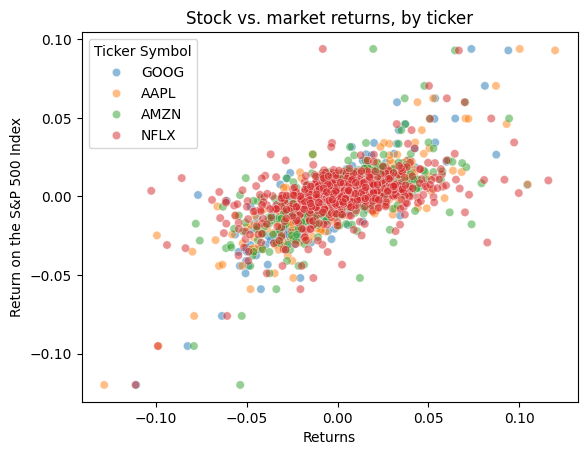

In [18]:
sns.scatterplot(data=df, x="Returns", y="Return on the S&P 500 Index", hue="Ticker Symbol", alpha=0.5) #alpha sets the transparency of each point, from 0 (fully invisible) to 1 (fully solid). 0.5 = 50% see-through.
plt.title("Stock vs. market returns, by ticker")
plt.show()

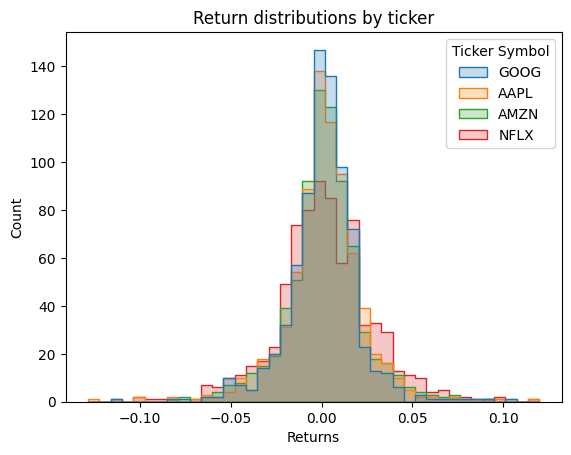

In [19]:
sns.histplot(data=df, x="Returns", hue="Ticker Symbol", bins=40, element="step")
plt.title("Return distributions by ticker")
plt.show()

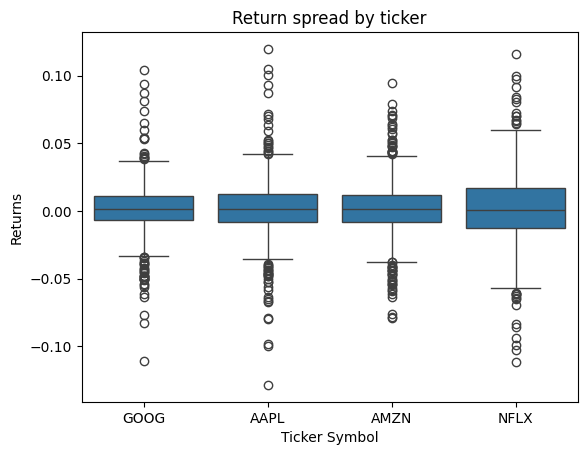

In [20]:
sns.boxplot(data=df, x="Ticker Symbol", y="Returns")
plt.title("Return spread by ticker")
plt.show()

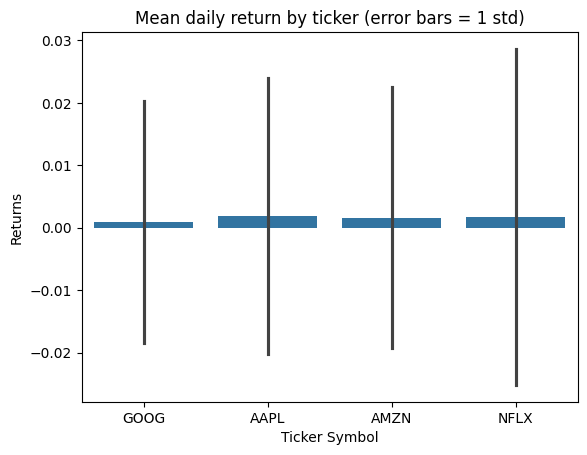

In [21]:
sns.barplot(data=df, x="Ticker Symbol", y="Returns", errorbar="sd")
plt.title("Mean daily return by ticker (error bars = 1 std)")
plt.show()

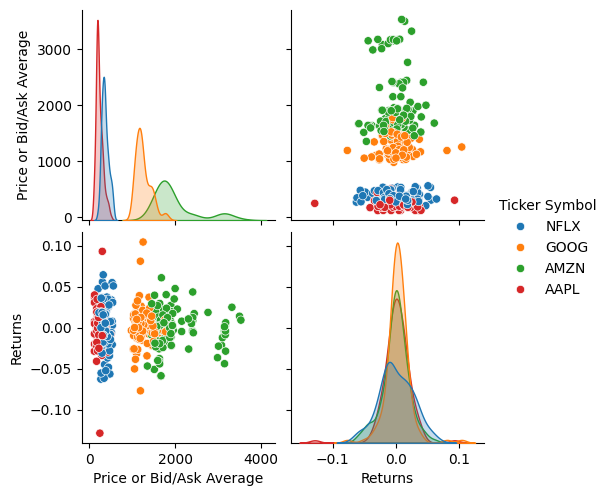

In [22]:
# a pairplot is a quick way to eyeball every pairwise relationship at once
sample = df[["Ticker Symbol", "Price or Bid/Ask Average", "Returns"]].sample(500, random_state=42)
sns.pairplot(sample, hue="Ticker Symbol", diag_kind="kde")
plt.show()

<span style="color:#b45309">**Exercise 1: Compare volatility visually**</span>

Using `sns.boxplot` or `sns.violinplot`, compare the *spread* of `Returns` across the four tickers. Which ticker looks the most volatile just from the plot -- and does that match what `groups["Returns"].std()` (from Block 1) told you numerically?

Try it in the cell below, then check the answer notebook (`Session 2b - Exercise Answers.ipynb`).


In [23]:
# your code here


## <span style="color:#1e3a8a">Exploratory Data Analysis (EDA)</span>

EDA (a term coined by John Tukey) means getting to know a dataset *before* you model or test
anything &mdash; descriptive stats, distributions, correlations, and spotting problems (missing
values, outliers) early. Skipping it is one of the most common causes of an analysis quietly
going wrong.

Let's switch datasets for a moment &mdash; `tips`, a classic small restaurant-bill dataset built
into Seaborn (loaded once and cached locally, so it only needs internet the first time).


In [24]:
tips = sns.load_dataset("tips")
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


### First look

Before any stats or plots, get the shape of the thing: how big is it, what columns exist, what type is each, and are any values missing? `.info()` answers all of that in one call.

In [ ]:
tips.info()

Row count, one line per column with its dtype and its **non-null** count (so any column whose non-null count is below the total row count has missing values), and memory use -- a fast first scan for problems.

### Descriptive statistics

In [25]:
tips.describe()

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


In [26]:
tips.describe(include="all")   # mixes numeric + categorical summaries in one table

,total_bill,tip,sex,smoker,day,time,size
count,244.000000,244.000000,244,244,244,244,244.000000
unique,NaN,NaN,2,2,4,2,NaN
top,NaN,NaN,Male,No,Sat,Dinner,NaN
freq,NaN,NaN,157,151,87,176,NaN
mean,19.785943,2.998279,NaN,NaN,NaN,NaN,2.569672
std,8.902412,1.383638,NaN,NaN,NaN,NaN,0.951100
min,3.070000,1.000000,NaN,NaN,NaN,NaN,1.000000
25%,13.347500,2.000000,NaN,NaN,NaN,NaN,2.000000
50%,17.795000,2.900000,NaN,NaN,NaN,NaN,2.000000
75%,24.127500,3.562500,NaN,NaN,NaN,NaN,3.000000


`.describe()` summarizes *numeric* columns well; for a **categorical** column the useful first move is `.value_counts()` -- how many rows fall in each category, and (with `normalize=True`) what share of the data that is:

In [ ]:
print(tips["day"].value_counts())
print()
print(tips["day"].value_counts(normalize=True).round(3))

### Distributions

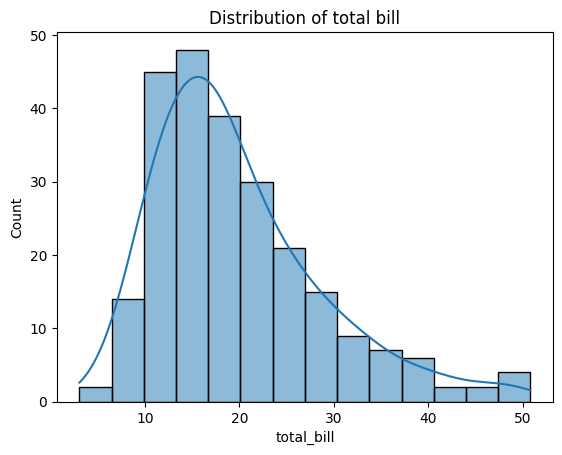

In [27]:
sns.histplot(data=tips, x="total_bill", kde=True)
plt.title("Distribution of total bill")
plt.show()

A **boxplot** is a compact alternative view of the same distribution -- the box spans the middle 50% (25th to 75th percentile), the line inside is the median, and dots beyond the whiskers are potential outliers:

In [ ]:
sns.boxplot(data=tips, y="total_bill")
plt.title("Total bill -- boxplot view")
plt.show()

print("skew:", round(tips["total_bill"].skew(), 2))

A positive **skew** (long right tail -- a few very large bills pulling the mean above the median) is typical for money variables. When it's strong, analysts sometimes work with `np.log(...)` of the variable instead, so the distribution is more symmetric.

### Correlation

In [28]:
corr = tips.select_dtypes("number").corr()
corr

,total_bill,tip,size
total_bill,1.000000,0.675734,0.598315
tip,0.675734,1.000000,0.489299
size,0.598315,0.489299,1.000000


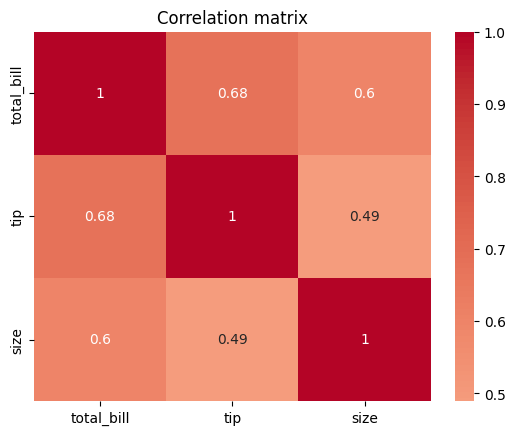

In [29]:
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation matrix")
plt.show()

A heatmap makes correlation structure easy to scan at a glance &mdash; but a correlation, on
its own, is a description of the data you have. It is **not** evidence that one variable causes
another; we'll come back to exactly this distinction properly on Day 3.

### Relationships between variables

A correlation is a single number. A plot shows you the *shape* of the relationship -- linear or curved, tight or loose, driven by a few outliers, or different for different groups.

In [ ]:
sns.scatterplot(data=tips, x="total_bill", y="tip")
plt.title("Do bigger bills get bigger tips?")
plt.show()

Clear positive relationship, but with real scatter -- and a grouped view can reveal structure a single correlation number hides:

In [ ]:
sns.boxplot(data=tips, x="day", y="tip", hue="smoker")
plt.title("Tip amount by day, split by smoker")
plt.show()

### Feature engineering from EDA

EDA isn't only passive looking -- it often tells you that a *derived* variable is the more meaningful thing to study. Here, a raw tip of \$3 means something very different on a \$10 bill than on a \$100 bill, so **tip percentage** is more comparable across bill sizes:

In [ ]:
tips["tip_pct"] = tips["tip"] / tips["total_bill"] * 100
tips["tip_pct"].describe()

In [ ]:
tips.groupby("day", observed=True)["tip_pct"].mean().round(2)

Now the comparison across days is on a like-for-like basis, and any day that looks unusual is unusual in *rate*, not just in raw dollars.

### Grouping and aggregation

In [30]:
tips.groupby("day", observed=True).agg(
    avg_bill=("total_bill", "mean"),
    avg_tip=("tip", "mean"),
    n=("total_bill", "size"),
)

,avg_bill,avg_tip,n
day,,,
Thur,17.682742,2.771452,62
Fri,17.151579,2.734737,19
Sat,20.441379,2.993103,87
Sun,21.410000,3.255132,76


### Missing values and outliers

In [31]:
tips.isna().sum()

total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size          0
dtype: int64

Alongside missing values, check for **duplicate rows** -- accidental repeats silently inflate counts and bias every statistic you compute afterward:

In [ ]:
tips.duplicated().sum()

In [32]:
# a quick, deliberately simple outlier check: values far from the mean in standard-deviation units
z = (tips["total_bill"] - tips["total_bill"].mean()) / tips["total_bill"].std()
tips[z.abs() > 3]

,total_bill,tip,sex,smoker,day,time,size
59,48.27,6.73,Male,No,Sat,Dinner,4
156,48.17,5.00,Male,No,Sun,Dinner,6
170,50.81,10.00,Male,Yes,Sat,Dinner,3
212,48.33,9.00,Male,No,Sat,Dinner,4


Zero missing values and no extreme outliers here &mdash; `tips` is a clean teaching dataset.
Real data essentially never is; check both, every time, before drawing conclusions.

### What to do with an outlier

An outlier is a **question, not an answer**. Before touching it:

1. **Look at the actual row(s).** Is the value plausible, or physically impossible (a negative age, a \$1,000,000 restaurant bill, a stock return of +5,000%)?
2. **Work out why it is there.** A data-entry or measurement error? A genuine rare event? A different population accidentally mixed into your data?
3. **Decide deliberately, and write down what you did:**
   - Clear error you cannot fix &rarr; remove it, and say so.
   - Genuine value &rarr; keep it. Where it might sway a result, report the analysis **with and without it** (a "robustness check"), so a reader can see its influence.
   - Never silently delete points just because they are inconvenient for the story you expected.

**And sometimes the outliers *are* the analysis** -- the thing you should filter *toward*, not away from:

- **Fraud detection**: the anomalous transactions are exactly the target. The unusual pattern is the signal, not noise.
- **Equipment / systems monitoring**: a sensor reading far outside its normal band is often the first sign of a fault -- that alert is the whole point of collecting the data.
- **Financial risk**: the handful of extreme-loss days (2008, March 2020) dominate real risk. A model that quietly drops them will badly *under*state how bad things can get -- the same idea as the "probability of a bad day" simulation back in Session 1.
- **Our own data**: the single biggest-return day in the tech-stocks set (AAPL, 13 March 2020, from Session 2a Exercise 2) is a return outlier -- and a genuinely meaningful one: pandemic-crash volatility, not a glitch. Deleting it would erase exactly the kind of day a risk analyst most needs to understand.


<span style="color:#b45309">**Exercise 2: EDA on the tech-stocks data**</span>

Apply the same three checks to `df` (the tech-stocks data): (1) a correlation heatmap between `Returns` and `Return on the S&P 500 Index`, (2) `df.isna().sum()`, (3) a simple z-score outlier check on `Returns`. Are there any missing values? Any days that look like outliers?

Try it in the cell below, then check the answer notebook (`Session 2b - Exercise Answers.ipynb`).


In [33]:
# your code here


## <span style="color:#1e3a8a">The EDA mindset</span>

EDA is a habit of thought as much as a set of commands:

- **It's iterative.** Every finding raises the next question -- you loop between summarizing, plotting, and cleaning, not run through once.
- **Watch for confirmation bias.** It's easy to keep looking only until you find something that matches what you expected. Deliberately look for what would *contradict* your hunch too.
- **A pattern is a hypothesis, not a conclusion.** An association you spot here is something to test carefully -- and it is never, on its own, evidence that one thing *causes* another (we'll treat that properly on Day 3).
- **Write down what you looked at**, not just what you found -- so you (and others) can tell whether a result is robust or cherry-picked.

## <span style="color:#1e3a8a">A note on Auto-EDA tools</span>

Tools like **`sweetviz`**, **`ydata-profiling`**, and **`pandas-profiling`** generate a full
descriptive report &mdash; distributions, correlations, missing-value summaries &mdash; from a
DataFrame in one line. They're a genuinely useful *first pass* on a new dataset.

They are not a substitute for actually looking at your data and thinking about it. An
auto-generated report can't tell you whether a correlation is spurious, whether a variable was
measured sensibly, or whether "no missing values" actually means "missing values were silently
coded as 0." Treat them as a fast starting point, not a finished analysis &mdash; especially since
the whole point of the EDA step above is to build your own judgment about the data, not outsource it.
